In [1]:
import os
from dotenv import load_dotenv

# 1. Manually trigger the 'search' for the .env file
load_dotenv()

# 2. Print a 'Truth Test' to the terminal
print(f"Diagnostic: Is the API Key found? {'Yes' if os.getenv('FRED_API_KEY') else 'No'}")

Diagnostic: Is the API Key found? Yes


In [2]:
from src.calculate_ratios import get_company_ratios

# Let's test it on Microsoft (MSFT) to make sure it's not just an 'Apple' thing
try:
    print("Testing the Credit Risk Scanner...")
    msft_stats = get_company_ratios("MSFT")
    print(f"Success! Microsoft Stats: {msft_stats}")
except Exception as e:
    print(f"Something went wrong: {e}")

Testing the Credit Risk Scanner...
Success! Microsoft Stats: {'interest_coverage': np.float64(52.84), 'debt_to_equity': np.float64(0.18)}


In [3]:
from src.download_fred_data import get_fred_data
from src.build_dataset import create_training_data
import pandas as pd

try:
    # 1. Pull Maahin's Macro Data (Now using your API Key!)
    print("Connecting to FRED...")
    macro_data = get_fred_data()

    # 2. Merge it with your Microsoft Health Scanner
    print("Building Master Dataset for MSFT...")
    # This function is the one we wrote in src/build_dataset.py
    master_table = create_training_data(macro_data, "MSFT")

    # 3. The Result
    print("\n--- MASTER DATASET PREVIEW ---")
    # We use .tail() to see the most recent days in April 2026
    print(master_table.tail())

    print(f"\nSuccess! Total Data Points: {len(master_table)}")
    print(f"Features: {master_table.columns.tolist()}")

except Exception as e:
    print(f"The pipeline broke here: {e}")

Connecting to FRED...
Requesting real-time series from St. Louis Fed...
Building Master Dataset for MSFT...

--- MASTER DATASET PREVIEW ---
            bbb_spread    vix  us10y  us2y  interest_coverage  debt_to_equity  \
2026-04-02        1.09  23.87   4.31  3.79              52.84            0.18   
2026-04-03        1.09  23.87   4.35  3.84              52.84            0.18   
2026-04-06        1.07  24.17   4.34  3.84              52.84            0.18   
2026-04-07        1.08  25.78   4.33  3.81              52.84            0.18   
2026-04-08        1.05  21.04   4.33  3.81              52.84            0.18   

            yield_curve_slope  spread_lag_1  
2026-04-02               0.52          1.10  
2026-04-03               0.51          1.09  
2026-04-06               0.50          1.09  
2026-04-07               0.52          1.07  
2026-04-08               0.52          1.08  

Success! Total Data Points: 7736
Features: ['bbb_spread', 'vix', 'us10y', 'us2y', 'interest_cove

In [4]:
from src.train_model import prepare_data_for_ml

# 1. Prep the ML data
X_train, X_test, y_train, y_test = prepare_data_for_ml(master_table)

# 2. The Check: Look at the "Shape" (Rows, Columns)
print("\n--- ML DATA SHAPE CHECK ---")
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")
print(f"Target Example (first 3): \n{y_train.head(3)}")


--- ML DATA SHAPE CHECK ---
Training Features Shape: (424, 7)
Testing Features Shape: (106, 7)
Target Example (first 3): 
2024-04-09    1.13
2024-04-10    1.11
2024-04-11    1.11
Name: bbb_spread, dtype: float64


In [5]:
from src.train_model import train_bond_model, evaluate_model

# 1. Train the model (Now using the 2-year filtered X_train/y_train)
model = train_bond_model(X_train, y_train)

# 2. Evaluate it
r2, mae = evaluate_model(model, X_test, y_test)

# 3. The Results
print("\n--- MODEL PERFORMANCE ---")
print(f"R-Squared Score: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.4f} (spread points)")

if r2 > 0.8:
    print("Status: Strong model! Ready for mispricing detection.")
elif r2 > 0:
    print(f"Status: Moderate model. Current R-Squared: {r2:.4f}. Much better than the -4.08!")
else:
    print("Status: Model is still weak. Check if 'X_train' still has 6,000+ rows.")
print(f"DEBUG: Training set starts at: {X_train.index.min()}")
print(f"DEBUG: Total training rows: {len(X_train)}")

Feeding 30 years of history into the Random Forest...

--- MODEL PERFORMANCE ---
R-Squared Score: 0.9047
Mean Absolute Error: 0.0133 (spread points)
Status: Strong model! Ready for mispricing detection.
DEBUG: Training set starts at: 2024-04-09 00:00:00
DEBUG: Total training rows: 424


In [6]:
from src.train_model import detect_mispricing

# 1. Find the mispriced dates
signals = detect_mispricing(model, X_test, y_test)

print("\n--- TOP BUY SIGNALS (CHEAPEST DAYS) ---")
print(signals.head(5))

print("\n--- TOP SELL SIGNALS (RICHEST DAYS) ---")
print(signals.tail(5))

# 2. Visual Check
current_mispricing = signals.iloc[0]['Mispricing_Bps']
print(f"\nMost Recent Mispricing: {current_mispricing:.2f} bps")


--- TOP BUY SIGNALS (CHEAPEST DAYS) ---
            Actual_Spread  Predicted_Fair_Value  Mispricing_Bps
2026-02-27           1.07                1.0209            4.91
2026-02-10           0.98                0.9580            2.20
2026-03-11           1.09                1.0682            2.18
2025-11-30           1.05                1.0293            2.07
2026-02-28           1.08                1.0599            2.01

--- TOP SELL SIGNALS (RICHEST DAYS) ---
            Actual_Spread  Predicted_Fair_Value  Mispricing_Bps
2026-04-06           1.07                1.1052           -3.52
2026-03-18           1.13                1.1703           -4.03
2026-03-20           1.11                1.1547           -4.47
2026-03-31           1.13                1.1772           -4.72
2026-04-01           1.10                1.1549           -5.49

Most Recent Mispricing: 4.91 bps


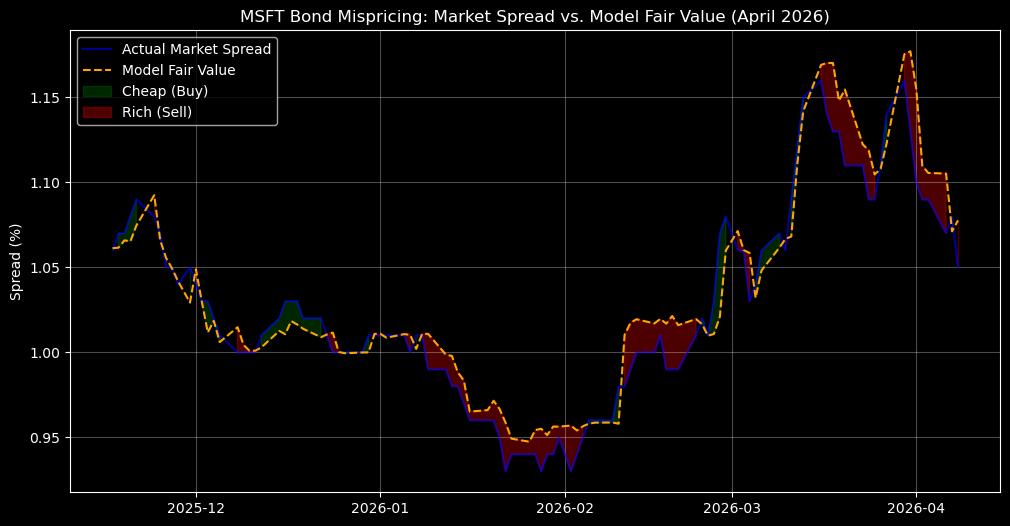

In [7]:
from src.visualize import plot_mispricing

# Trigger the plot
plot_mispricing(signals)